# **Classification Project:** MNIST
29/03/2026, Louie Leverett

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
plt.style.use('default')

import numpy as np

### Extract mnist dataset and display sample of figures

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', parser='pandas')

In [3]:
X, y = mnist["data"].to_numpy(), mnist["target"].to_numpy()
print(f"Num images: {X.shape[0]}, Num features (pixels): {X.shape[1]}")

Num images: 70000, Num features (pixels): 784


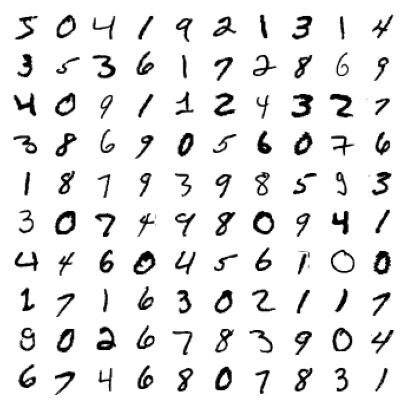

In [6]:
# display sample of digits
fig, axis = plt.subplots(10, 10, figsize=(5, 5))
labels = ""
for i, ax in enumerate(axis.flat):
    example_digit = X[i].reshape(28, 28)
    labels = labels + f"{y[i]}, "
    ax.imshow(example_digit, cmap='binary');
    ax.axis("off")
# print(labels)

Histogram of labels

### Evaluate distribution of figures

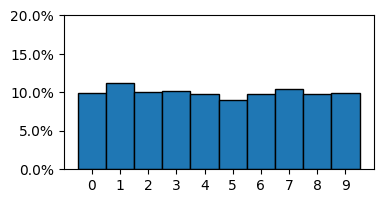

In [7]:
yy = np.sort(y)
plt.figure(figsize=(4, 2))
plt.hist(yy, weights=np.ones(len(y)) / len(y), bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], align="left", edgecolor = "black")
plt.ylim(0.0, 0.2)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

### Create training and test sets

Training set = first 60,0000; Test set = last 10,000 images

**Note:** the training set is already shuffled

In [8]:
from sklearn.model_selection import train_test_split

# flatten image data
n_samples = len(X)
X = X.reshape((n_samples, -1))

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

X_train = X_train[:2000]
y_train = y_train[:2000]

### Select and Train a Model

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

In [10]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter("ignore", category=ConvergenceWarning)

Creating a basic preprocessing pipline with multiple models

In [31]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [32]:
preprocessing = make_pipeline(StandardScaler())

classifier_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", SGDClassifier(random_state=42)), # place holder model
])

Apply Grid Search to find good parameters

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
param_grid = [
    { # model 1
        'model': [SGDClassifier(random_state=42)],
        'model__loss': ["hinge", "log_loss", "modified_huber"],
        'model__alpha': [1e-4, 1e-3, 1e-2],
    },
    { # model 2
        'model': [RandomForestClassifier(random_state=42)],
        'model__n_estimators': [100, 300],
        'model__max_depth': [None, 20, 40],
    },
    { # model 3 - Extra Trees
        "model": [ExtraTreesClassifier(random_state=42)],
        "model__n_estimators": [100, 300],
        "model__max_features": ["sqrt", "log2"],
    },
]

In [35]:
grid_search = GridSearchCV(
    classifier_pipeline, 
    param_grid, 
    cv=3, 
    scoring="accuracy"
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'model': ExtraTreesClassifier(random_state=42), 'model__max_features': 'sqrt', 'model__n_estimators': 300}


In [52]:
print(grid_search.best_score_)
print(grid_search.best_estimator_.score(X_test, y_test))

0.9150042096069083
0.9312857142857143


In [54]:
import pandas as pd
results = pd.DataFrame(grid_search.cv_results_)
results[["param_model", "param_model__loss", "param_model__n_estimators", "mean_test_score"]].sort_values("mean_test_score", ascending=False)

,param_model,param_model__loss,param_model__n_estimators,mean_test_score
16,ExtraTreesClassifier(random_state=42),NaN,300.0,0.915004
18,ExtraTreesClassifier(random_state=42),NaN,300.0,0.908511
15,ExtraTreesClassifier(random_state=42),NaN,100.0,0.908507
12,RandomForestClassifier(random_state=42),NaN,300.0,0.908005
14,RandomForestClassifier(random_state=42),NaN,300.0,0.908005
10,RandomForestClassifier(random_state=42),NaN,300.0,0.908005
11,RandomForestClassifier(random_state=42),NaN,100.0,0.903505
13,RandomForestClassifier(random_state=42),NaN,100.0,0.903505
9,RandomForestClassifier(random_state=42),NaN,100.0,0.903505
17,ExtraTreesClassifier(random_state=42),NaN,100.0,0.902009


Comparing Confusing Matrix's

In [56]:
from sklearn.metrics import classification_report
y_pred = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1373
           1       0.97      0.99      0.98      1569
           2       0.93      0.93      0.93      1430
           3       0.94      0.91      0.93      1413
           4       0.92      0.92      0.92      1376
           5       0.92      0.91      0.91      1253
           6       0.94      0.96      0.95      1339
           7       0.94      0.93      0.93      1483
           8       0.95      0.86      0.90      1365
           9       0.85      0.93      0.89      1399

    accuracy                           0.93     14000
   macro avg       0.93      0.93      0.93     14000
weighted avg       0.93      0.93      0.93     14000



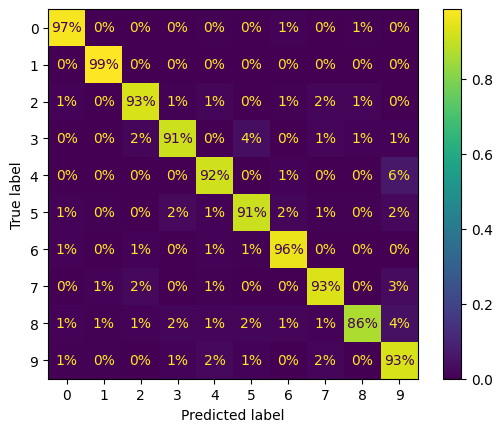

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X_test, y_test, normalize="true", values_format=".0%")
plt.show()

Evaluating the classification report and confusion matrix, the figure '9' is the weakest class. It has the lowest precision and f1-score. My model predicts 9 to true labels such as  4 and 8. 9 Shares visual features with 4 (the top loop/step) and 8 (overall roundness).

Dig into the errors (error analysis)

In [72]:
# Get indices where true label is 9 but model got it wrong
mask = np.where((y_test == '9') & (y_test != y_pred))
print(mask)
wrong_9s = X_test[mask]
wrong_labels = y_pred[mask]

(array([   90,   292,   348,   464,   480,   773,   774,   800,   839,
        1159,  1667,  1683,  1728,  1729,  1732,  2159,  2413,  2470,
        3314,  3344,  3719,  3942,  3948,  4073,  4320,  4448,  4479,
        4882,  5107,  5192,  5228,  5232,  5247,  5553,  5559,  5627,
        5709,  5781,  5901,  5952,  6009,  6129,  6189,  6293,  6342,
        6380,  6387,  6406,  6426,  6648,  6735,  6939,  7005,  7060,
        7240,  7369,  7394,  7503,  7597,  7664,  7716,  7820,  7821,
        7850,  7884,  7926,  8000,  8078,  8093,  8163,  8224,  8294,
        8344,  8500,  8511,  8633,  8665,  8679,  8823,  8874,  9001,
        9135,  9311, 10071, 10081, 10091, 10112, 10126, 10157, 10166,
       10172, 10173, 10505, 10560, 10571, 10740, 12332, 13642, 13741,
       13808, 13890, 13891]),)


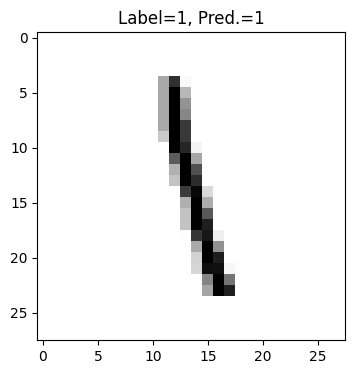

In [63]:
fig, ax = plt.subplots(figsize=(4,4))

i = 20
example_digit = X_test[i].reshape(28, 28)

ax.imshow(example_digit, cmap='binary')
ax.set_title(f"Label={y_test[i]}, Pred.={y_pred[i]}")
plt.show()

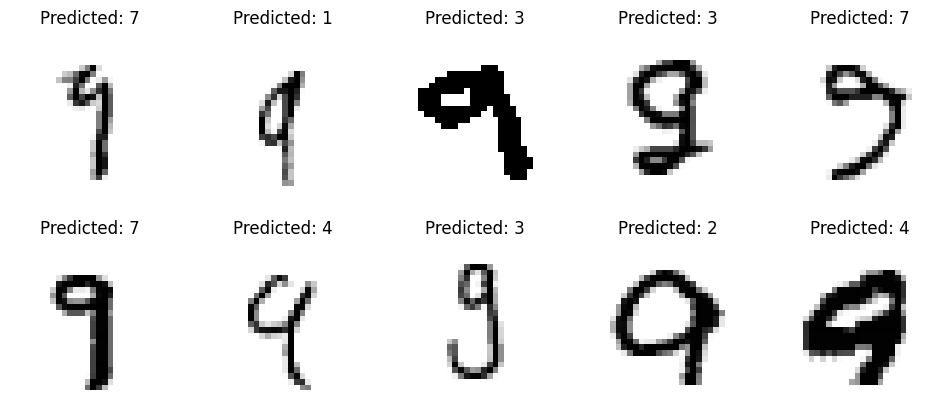

In [74]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, pred in zip(axes.flat, wrong_9s[:10], wrong_labels[:10]):
    ax.imshow(img.reshape(28, 28), cmap="binary")
    ax.set_title(f"Predicted: {pred}")
    ax.axis("off")

Train the model on a larger training

In [85]:
print(grid_search.best_estimator_)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('standardscaler', StandardScaler())])),
                ('model',
                 ExtraTreesClassifier(n_estimators=300, random_state=42))])


In [89]:
preprocessing = make_pipeline(StandardScaler())

extra_trees_classifier_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("ExtraTreesClassifier", 
     ExtraTreesClassifier(n_estimators=300, random_state=42)
    ),
])

extra_trees_classifier_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('ExtraTreesClassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (

In [92]:
y_pred = extra_trees_classifier_pipeline.predict(X_test)
score = extra_trees_classifier_pipeline.score(X_test, y_test)
print(f"{score:.3f}")
print(classification_report(y_test, y_pred))

0.931
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1373
           1       0.97      0.99      0.98      1569
           2       0.93      0.93      0.93      1430
           3       0.94      0.91      0.93      1413
           4       0.92      0.92      0.92      1376
           5       0.92      0.91      0.91      1253
           6       0.94      0.96      0.95      1339
           7       0.94      0.93      0.93      1483
           8       0.95      0.86      0.90      1365
           9       0.85      0.93      0.89      1399

    accuracy                           0.93     14000
   macro avg       0.93      0.93      0.93     14000
weighted avg       0.93      0.93      0.93     14000

